C:\Users\91807\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\91807\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\91807\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\91807\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelih

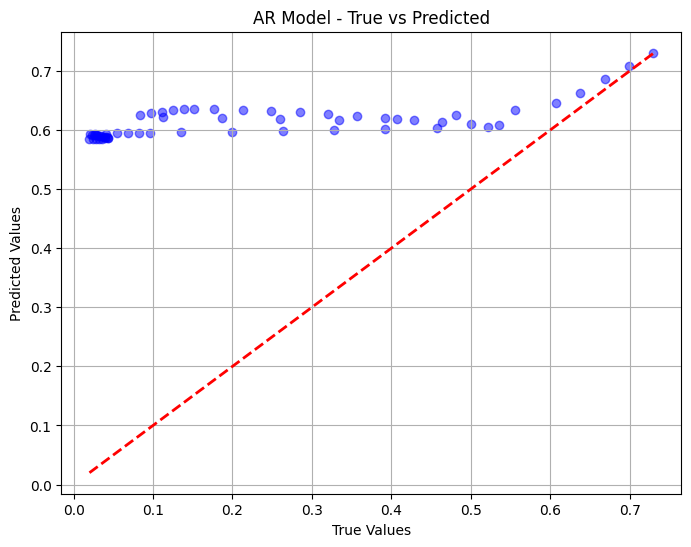

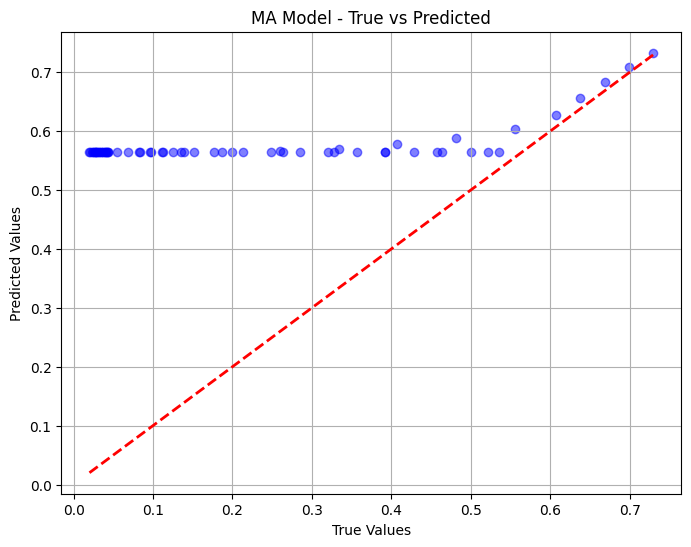

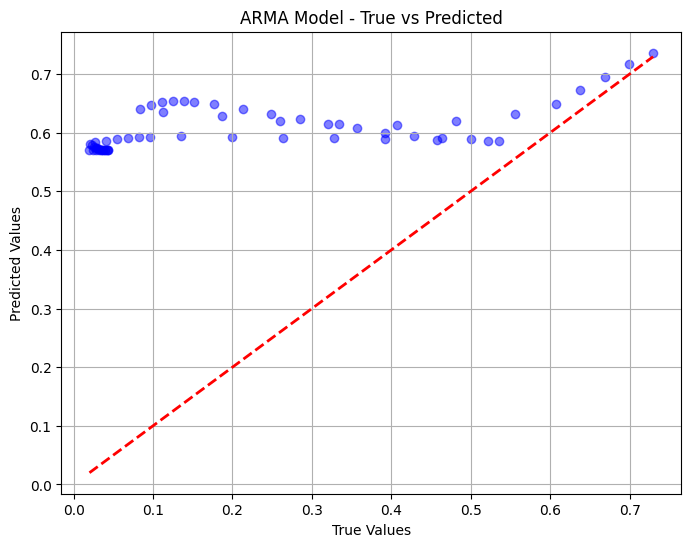

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

data = pd.read_csv('Location1.csv')
data=data.head(300)
train_size = int(0.8 * len(data['Power'].dropna()))
train_data = data['Power'][:train_size]
test_data = data['Power'][train_size:]


ar_model = ARIMA(train_data, order=(10, 0, 0)).fit()
ar_forecast = ar_model.forecast(steps=len(test_data))
ar_mae = mean_absolute_error(test_data, ar_forecast)
ar_mse = mean_squared_error(test_data, ar_forecast)


ma_model = ARIMA(train_data, order=(0, 0, 10)).fit()
ma_forecast = ma_model.forecast(steps=len(test_data))
ma_mae = mean_absolute_error(test_data, ma_forecast)
ma_mse = mean_squared_error(test_data, ma_forecast)


arma_model = ARIMA(train_data, order=(10, 0, 10)).fit()
arma_forecast = arma_model.forecast(steps=len(test_data))
arma_mae = mean_absolute_error(test_data, arma_forecast)
arma_mse = mean_squared_error(test_data, arma_forecast)


def plot_results(true_values, predictions, model_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(true_values, predictions, alpha=0.5, color='blue')
    plt.plot([true_values.min(), true_values.max()],
             [true_values.min(), true_values.max()],
             color='red', linestyle='--', linewidth=2)
    plt.title(f'{model_name} - True vs Predicted')
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.grid()
    plt.show()

  
   

plot_results(test_data, ar_forecast, 'AR Model')
plot_results(test_data, ma_forecast, 'MA Model')
plot_results(test_data, arma_forecast, 'ARMA Model')


0.3502214174949668 0.15849120315731516
0.38152531170897397 0.18169296699993592
0.3872976416569316 0.18614891212323528


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
ar_r2 = r2_score(test_data, ar_forecast)
ma_r2 = r2_score(test_data, ma_forecast)
arma_r2 = r2_score(test_data, arma_forecast)
print(f"AR Model - MAE: {ar_mae:.4f}, MSE: {ar_mse:.4f}, R2: {ar_r2:.4f}")
print(f"MA Model - MAE: {ma_mae:.4f}, MSE: {ma_mse:.4f}, R2: {ma_r2:.4f}")
print(f"ARMA Model - MAE: {arma_mae:.4f}, MSE: {arma_mse:.4f}, R2: {arma_r2:.4f}")

AR Model - MAE: 0.3873, MSE: 0.1861, R2: -3.2041
MA Model - MAE: 0.3502, MSE: 0.1585, R2: -2.5795
ARMA Model - MAE: 0.3813, MSE: 0.1816, R2: -3.1008
